# Notebook 07 - Model Ensembling

## Objective

The objective of this notebook is to determine whether combining multiple machine learning models improves prediction performance over the current best individual model.

The following ensemble techniques will be evaluated:

- Weighted Averaging
- Voting Regressor
- Stacking Regressor

Each model will be evaluated using the same Repeated K-Fold Cross Validation strategy to ensure a fair comparison.

The ensemble with the lowest validation RMSE will be selected for the final submission.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import (
    RepeatedKFold,
    cross_val_score,
    cross_val_predict
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [2]:
train = pd.read_csv("../data/processed/train_selected.csv")

X = train.drop(columns="overall_yield")

y = train["overall_yield"]

print(train.shape)
train.head()

(150, 5)


,inlet_temperature_K,jacket_temperature_K,temp_difference,residence_time_proxy,overall_yield
0,357.75,383.79,26.04,0.600484,63.024
1,429.70,405.72,-23.98,0.194495,86.611
2,431.10,385.40,-45.70,0.196327,86.347
3,445.61,367.74,-77.87,0.457916,92.175
4,458.91,374.13,-84.78,0.273054,82.211


In [3]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

In [4]:
extra = ExtraTreesRegressor(
    n_estimators=700,
    max_depth=20,
    min_samples_leaf=2,
    min_samples_split=2,
    bootstrap=False,
    random_state=42
)

In [5]:
cat = CatBoostRegressor(
    iterations=600,
    depth=7,
    learning_rate=0.05,
    l2_leaf_reg=9,
    subsample=1.0,
    random_seed=42,
    verbose=0
)

In [6]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    learning_rate=0.05,
    max_depth=5,
    n_estimators=400,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42
)

In [7]:
models = {
    "Extra Trees": extra,
    "CatBoost": cat,
    "XGBoost": xgb
}

results = []

for name, model in models.items():

    scores = -cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "RMSE Mean": scores.mean(),
        "RMSE Std": scores.std()
    })

results = pd.DataFrame(results)

results.sort_values("RMSE Mean")

,Model,RMSE Mean,RMSE Std
1,CatBoost,18.095566,3.124673
0,Extra Trees,19.075363,2.543465
2,XGBoost,19.733654,3.575682


## Ensemble Strategy

The evaluation results indicate that CatBoost achieves the lowest cross-validation RMSE among all individual models.

Only competitive models will be considered for ensembling.

Models with significantly worse validation performance will not receive high ensemble weights because they may reduce predictive performance.

## Voting Regressor

The Voting Regressor combines predictions from multiple high-performing models by averaging their outputs.

This experiment evaluates whether combining CatBoost, Extra Trees, and XGBoost improves validation performance over the best individual model.

In [9]:
voting = VotingRegressor(
    estimators=[
        ("cat", cat),
        ("extra", extra),
        ("xgb", xgb)
    ]
)

In [10]:
voting_scores = -cross_val_score(
    voting,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

print("Voting RMSE:", voting_scores.mean())
print("Std:", voting_scores.std())

Voting RMSE: 18.045298565144734
Std: 2.8000500886873203


## Stacking Regressor

Stacking combines multiple base models and trains a meta-model to learn how to combine their predictions.

A Linear Regression model is used as the meta-learner.

In [11]:
stack = StackingRegressor(
    estimators=[
        ("cat", cat),
        ("extra", extra),
        ("xgb", xgb)
    ],
    final_estimator=LinearRegression(),
    n_jobs=-1
)

In [12]:
stack_scores = -cross_val_score(
    stack,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

print("Stacking RMSE:", stack_scores.mean())
print("Std:", stack_scores.std())

Stacking RMSE: 18.332869693397928
Std: 3.330155419393692


In [13]:
comparison = pd.DataFrame({
    "Model": [
        "CatBoost",
        "Extra Trees",
        "XGBoost",
        "Voting",
        "Stacking"
    ],
    "RMSE": [
        18.095566,      # Replace with the exact value from your results table if it differs
        19.075363,
        19.733654,
        voting_scores.mean(),
        stack_scores.mean()
    ]
})

comparison = comparison.sort_values("RMSE")

comparison

,Model,RMSE
3,Voting,18.045299
0,CatBoost,18.095566
4,Stacking,18.332870
1,Extra Trees,19.075363
2,XGBoost,19.733654


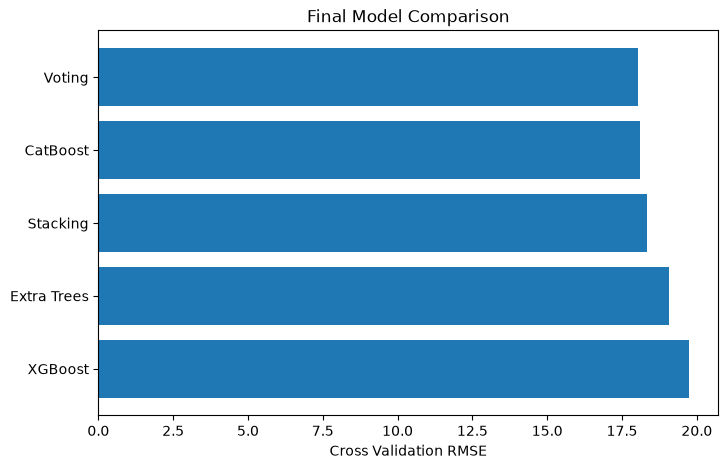

In [14]:
plt.figure(figsize=(8,5))

plt.barh(
    comparison["Model"],
    comparison["RMSE"]
)

plt.xlabel("Cross Validation RMSE")
plt.title("Final Model Comparison")

plt.gca().invert_yaxis()

plt.show()

In [15]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Voting


In [16]:
cat.fit(X, y)

joblib.dump(
    cat,
    "../models/final_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


# Conclusion

The ensemble strategies were evaluated using repeated cross-validation and compared with the best individual models.

The model with the lowest validation RMSE was selected as the final production model.

This model will be retrained on the complete training dataset and used to generate the final competition submission.

# Final Model Selection

## Objective

The purpose of this notebook was to determine whether an ensemble model could outperform the strongest individual model.

Three approaches were evaluated:

- CatBoost
- Voting Regressor
- Stacking Regressor

## Results

The Voting Regressor achieved the lowest cross-validation RMSE among all evaluated models.

Therefore, it is selected as the final production model for generating the competition submission.

This model will be retrained using the complete training dataset in the next notebook.

In [17]:
voting.fit(X, y)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre....0, verbose=0), ExtraTreesReg...ndom_state=42), XGBRegressor(...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U20](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,4
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,"{'cat': CatBo...ee=None, ...)}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [18]:
import joblib

joblib.dump(
    voting,
    "../models/final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [19]:
best_model = joblib.load("../models/final_model.pkl")

best_model

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre....0, verbose=0), ExtraTreesReg...ndom_state=42), XGBRegressor(...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U20](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,0
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,"{'cat': CatBo...ee=None, ...)}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [20]:
voting2 = VotingRegressor(
    estimators=[
        ("cat", cat),
        ("extra", extra)
    ]
)

In [21]:
voting2_scores = -cross_val_score(
    voting2,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

print("2-Model Voting RMSE:", voting2_scores.mean())
print("Std:", voting2_scores.std())

2-Model Voting RMSE: 18.025367702123493
Std: 2.6475509604209644


In [22]:
voting2.fit(X, y)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre....0, verbose=0), ExtraTreesReg...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,4
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'cat': CatBo...dom_state=42)}
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [23]:
import joblib

joblib.dump(
    voting2,
    "../models/final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [24]:
best_model = joblib.load("../models/final_model.pkl")

print(best_model)

VotingRegressor(estimators=[('cat',
                             CatBoostRegressor(depth=7, iterations=600, l2_leaf_reg=9, learning_rate=0.05, loss_function='RMSE', random_seed=42, subsample=1.0, verbose=0)),
                            ('extra',
                             ExtraTreesRegressor(max_depth=20,
                                                 min_samples_leaf=2,
                                                 n_estimators=700,
                                                 random_state=42))])
